# Notebook 3: Ensemble Methods - The Power of Many

Ghana AI Talent Accelerator - Machine Learning Foundations

Ghana AI Accelerator

# 1. The Wisdom of Crowds

### Why Combine Models?

In previous notebooks, we learned about individual models: - **Linear
Regression**: Simple, interpretable baseline - **Logistic Regression**:
Good for classification with linear boundaries - **Decision Tree**:
Interpretable, captures non-linear patterns

Each model has weaknesses. **Ensemble methods** combine multiple models
to create a stronger predictor.

### The Wisdom of Crowds Analogy

Imagine you want to estimate the weight of an ox at a fair:

**Scenario 1: Ask one expert**

-   Expert guesses: 1,200 kg
-   Actual weight: 1,198 kg
-   Error: 2 kg

**Scenario 2: Ask 100 random people**

-   Each person guesses different values
-   Average of all guesses: 1,200 kg
-   Error: 2 kg

**Result**: The crowd’s average is often as accurate as the expert’s
best guess!

**Why it works**:

-   Individual errors are random and cancel out
-   Wisdom comes from diversity, not just expertise

> **Key Insight: Ensembles in Machine Learning**
>
> Instead of asking 100 people to guess an ox’s weight, we train 100
> models to predict the same target. Then we combine their predictions
> (by voting or averaging) to get a better result.

### The Two Main Approaches

| Approach | How It Works | Example |
|:-----------------------|:-----------------------|:-----------------------|
| **Bagging** | Train models independently in parallel, then average/vote | Random Forest |
| **Boosting** | Train models sequentially, each correcting previous mistakes | Gradient Boosting, XGBoost |

------------------------------------------------------------------------

# 2. Bagging - Bootstrap Aggregating

### How Bagging Works

**Bagging** (Bootstrap Aggregating) creates multiple models using random
subsets of data:

1.  **Create multiple datasets**: Sample with replacement from original
    data
2.  **Train multiple models**: Each model learns from its own dataset
3.  **Combine predictions**: Average (regression) or vote
    (classification)

``` text
Original Data (100 samples)
├── Sample 1 (100 samples with replacement) → Model 1
├── Sample 2 (100 samples with replacement) → Model 2
├── Sample 3 (100 samples with replacement) → Model 3
└── ... repeat 100 times ...

Final Prediction = Average/Majority vote of all models
```

### Random Forest: The Most Popular Bagging Algorithm

Random Forest is bagging applied to decision trees, with one key twist:

-   **Random feature selection**: Each tree only sees a random subset of
    features at each split

This makes trees more diverse, reducing overfitting and improving
performance.

### Key Parameters

| Parameter | Description | Typical Values |
|:-----------------------|:-----------------------|:-----------------------|
| `n_estimators` | Number of trees | 100-1000 |
| `max_depth` | Maximum tree depth | 5-20 (or None) |
| `min_samples_split` | Minimum samples to split a node | 2-20 |
| `min_samples_leaf` | Minimum samples in a leaf | 1-10 |
| `max_features` | Features considered at each split | ‘sqrt’, ‘log2’, or number |

### Training a Random Forest Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load Ghana housing data
df_ghana = pd.read_csv('data/house_rentals.csv')

# Prepare features and target
features_for_model = [
    'bedrooms', 'bathrooms', 'floor_area', 
    'category', 'region', 'condition', 'parking_space', 'is_furnished'
]
df_model = df_ghana[features_for_model + ['price']].copy()

# Handle missing values
df_model = df_model.dropna(subset=['bedrooms', 'bathrooms', 'floor_area', 'price'])
df_model['condition'] = df_model['condition'].fillna(df_model['condition'].mode()[0])

# Handle outliers
q_low = df_model['price'].quantile(0.005)
q_high = df_model['price'].quantile(0.995)
df_model = df_model[(df_model['price'] >= q_low) & (df_model['price'] <= q_high)]

# One-hot encode
df_encoded = pd.get_dummies(df_model, 
                          columns=['category', 'region', 'condition', 'is_furnished'],
                          drop_first=True)

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

print("✅ Random Forest Regressor trained!")
print(f"Number of trees: {rf.n_estimators}")
print(f"Max depth: {rf.max_depth}")
print(f"Number of features used at each split: {rf.max_features}")

✅ Random Forest Regressor trained!
Number of trees: 100
Max depth: 10
Number of features used at each split: sqrt

### Evaluating Random Forest Regressor

In [2]:
# Make predictions
y_pred_rf = rf.predict(X_test)

# Metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Performance:")
print(f"  RMSE: ₵{rmse_rf:,.2f}")
print(f"  R² Score: {r2_rf:.3f}")

# Cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"  CV R²: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")

Random Forest Performance:
  RMSE: ₵6,702.46
  R² Score: 0.522
  CV R²: 0.503 (±0.014)

### Feature Importance: Which Features Matter Most?

Random Forest provides a powerful feature: **feature importance**—which
features contribute most to predictions.

In [3]:
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance.head(15))

Feature Importance:
                        Feature  Importance
1                     bathrooms    0.256341
0                      bedrooms    0.233843
19     is_furnished_Unfurnished    0.125072
18  is_furnished_Semi-Furnished    0.122644
5                category_Flats    0.088978
2                    floor_area    0.067179
8            category_Townhouse    0.045618
12         region_Greater Accra    0.029898
17               condition_Used    0.008473
6              category_Mansion    0.006828
4               category_Duplex    0.004512
10        region_Central Region    0.003188
16          condition_Renovated    0.002721
13       region_Northern Region    0.002652
7        category_Semi-Detached    0.000835

### Visualizing Feature Importance

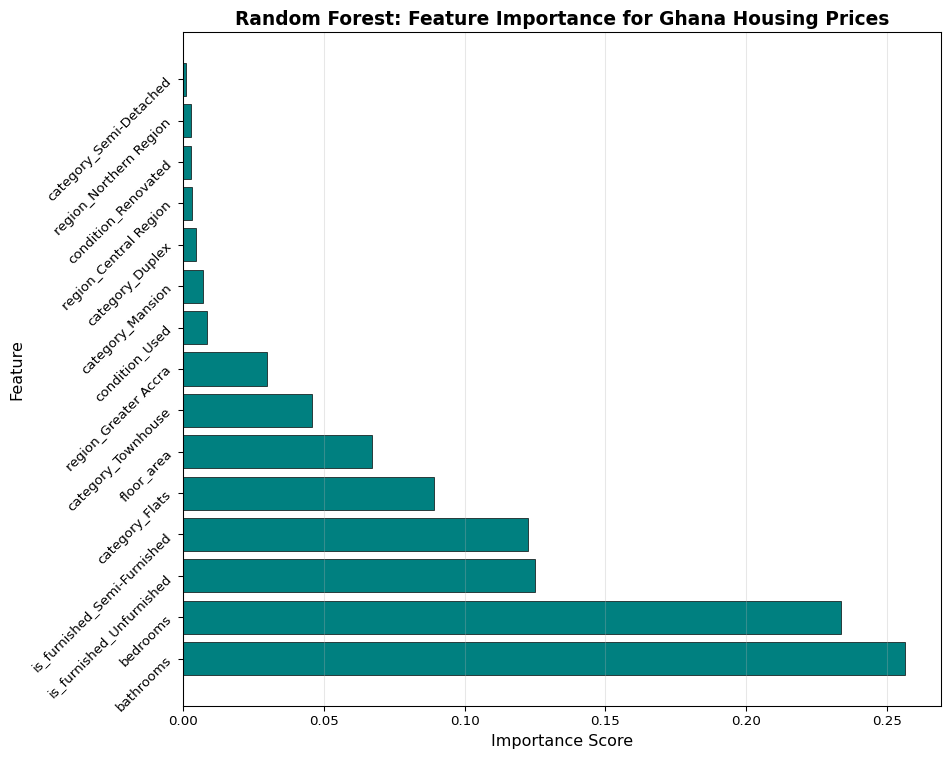

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

# Sort by importance and get top 15
feature_importance_sorted = feature_importance.head(15).sort_values('Importance', ascending=True)

# Create horizontal bar plot
ax.barh(feature_importance_sorted['Feature'], feature_importance_sorted['Importance'], 
        color='teal', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Random Forest: Feature Importance for Ghana Housing Prices', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Put most important feature at top
ax.grid(True, alpha=0.3, axis='x')
ax.tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Comparing Random Forest vs. Single Decision Tree Regressor

In [5]:
from sklearn.tree import DecisionTreeRegressor

# Single decision tree
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Compare
r2_dt = r2_score(y_test, dt.predict(X_test))
r2_rf = r2_score(y_test, rf.predict(X_test))

print(f"Decision Tree R²: {r2_dt:.3f}")
print(f"Random Forest R²: {r2_rf:.3f}")
print(f"Improvement: {(r2_rf - r2_dt) / abs(r2_dt) * 100:.1f}%")

Decision Tree R²: 0.475
Random Forest R²: 0.528
Improvement: 11.2%

> **Why Random Forest Beats Single Trees**
>
> 1.  **Reduces Overfitting**: Each tree sees different data, errors
>     don’t all align
> 2.  **Reduces Variance**: Averaging many predictions is more stable
>     than one
> 3.  **Captures More Patterns**: Different trees focus on different
>     features
> 4.  **Robust to Outliers**: One bad tree doesn’t ruin the ensemble

------------------------------------------------------------------------

# 3. Boosting - Learning from Mistakes

### How Boosting Works

**Boosting** trains models sequentially—each new model focuses on
correcting errors from previous models:

1.  **Train first model**: Makes some errors
2.  **Train second model**: Focuses on examples first model got wrong
3.  **Train third model**: Focuses on examples second model got wrong
4.  **Repeat**: Each model corrects previous mistakes
5.  **Combine**: Weighted sum of all predictions

``` text
Iteration 1: Model 1 → 80% accuracy (20% errors)
Iteration 2: Model 2 → Focuses on Model 1's errors → 60% on errors
Iteration 3: Model 3 → Focuses on Model 2's errors → 40% on remaining errors
...

Final Prediction = Weighted sum of all models
```

### Gradient Boosting: The Foundation

Gradient Boosting uses **gradient descent** to minimize errors:

-   Treat training like optimization problem
-   Each new model moves prediction in direction of steepest error
    reduction
-   Model learns by following the “gradient” of errors

### Key Differences: Bagging vs. Boosting

| Aspect | Bagging (Random Forest) | Boosting (Gradient Boosting) |
|:-----------------------|:-----------------------|:-----------------------|
| **Training** | Models in parallel (independent) | Models sequentially (dependent) |
| **Focus** | Each model learns from all data | Each model focuses on errors |
| **Bias-Variance** | Reduces variance | Reduces both bias and variance |
| **Speed** | Fast (can parallelize) | Slower (sequential) |
| **Overfitting** | Less prone | More prone (needs tuning) |

### Training a Gradient Boosting Regressor

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

# Train Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

print("✅ Gradient Boosting Regressor trained!")
print(f"Number of estimators: {gb.n_estimators}")
print(f"Learning rate: {gb.learning_rate}")
print(f"Max depth: {gb.max_depth}")

✅ Gradient Boosting Regressor trained!
Number of estimators: 100
Learning rate: 0.1
Max depth: 3

### Evaluating Gradient Boosting Regressor

In [7]:
# Make predictions
y_pred_gb = gb.predict(X_test)

# Metrics
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting Performance:")
print(f"  RMSE: ₵{rmse_gb:,.2f}")
print(f"  R² Score: {r2_gb:.3f}")

# Cross-validation
cv_scores_gb = cross_val_score(gb, X_train, y_train, cv=5, scoring='r2')
print(f"  CV R²: {cv_scores_gb.mean():.3f} (±{cv_scores_gb.std():.3f})")

Gradient Boosting Performance:
  RMSE: ₵6,640.30
  R² Score: 0.530
  CV R²: 0.513 (±0.022)

### XGBoost: The State-of-the-Art

**XGBoost** (eXtreme Gradient Boosting) is the most popular boosting
algorithm:

**Key improvements over standard Gradient Boosting:**

1.  **Regularization**: L1 and L2 regularization to prevent overfitting
2.  **Speed**: Optimized implementation (faster training)
3.  **Parallelization**: Can parallelize tree construction
4.  **Handling Missing Values**: Automatically handles missing data
5.  **Tree Pruning**: More sophisticated pruning strategy

### Training XGBoost Regressor

In [8]:
from xgboost import XGBRegressor

# Train XGBoost
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

print("✅ XGBoost Regressor trained!")
print(f"Number of estimators: {xgb.n_estimators}")
print(f"Learning rate: {xgb.learning_rate}")
print(f"Max depth: {xgb.max_depth}")

✅ XGBoost Regressor trained!
Number of estimators: 100
Learning rate: 0.1
Max depth: 3

### Evaluating XGBoost Regressor

In [9]:
# Make predictions
y_pred_xgb = xgb.predict(X_test)

# Metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Performance:")
print(f"  RMSE: ₵{rmse_xgb:,.2f}")
print(f"  R² Score: {r2_xgb:.3f}")

# Cross-validation
cv_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2')
print(f"  CV R²: {cv_scores_xgb.mean():.3f} (±{cv_scores_xgb.std():.3f})")

XGBoost Performance:
  RMSE: ₵6,634.19
  R² Score: 0.531
  CV R²: 0.513 (±0.022)

------------------------------------------------------------------------

# 4. Complete Ensemble Pipeline: Regression on Ghana Housing Data

Let’s build a complete pipeline comparing all ensemble regression
methods on the Ghana housing dataset.

### Step 1: Data Preparation

In [10]:
# Load Ghana housing data
df_ghana = pd.read_csv('data/house_rentals.csv')

# Prepare features
features_for_model = [
    'bedrooms', 'bathrooms', 'floor_area', 
    'category', 'region', 'condition', 'parking_space', 'is_furnished'
]
df_model = df_ghana[features_for_model + ['price']].copy()

# Handle missing values
df_model = df_model.dropna(subset=['bedrooms', 'bathrooms', 'floor_area', 'price'])
df_model['condition'] = df_model['condition'].fillna(df_model['condition'].mode()[0])

# Handle outliers
q_low = df_model['price'].quantile(0.005)
q_high = df_model['price'].quantile(0.995)
df_model = df_model[(df_model['price'] >= q_low) & (df_model['price'] <= q_high)]

# One-hot encode
df_encoded = pd.get_dummies(df_model, 
                          columns=['category', 'region', 'condition', 'is_furnished'],
                          drop_first=True)

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Training set: 14186 samples
Test set: 3547 samples
Features: 20

### Step 2: Train Multiple Models

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize models
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

# Train all models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'model': model,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred
    }
    
    print(f"{name}:")
    print(f"  RMSE: ₵{rmse:,.2f}")
    print(f"  R² Score: {r2:.3f}")
    print(f"  CV R²: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    print()

Decision Tree:
  RMSE: ₵6,989.78
  R² Score: 0.480
  CV R²: 0.453 (±0.017)

Random Forest:
  RMSE: ₵6,660.65
  R² Score: 0.528
  CV R²: 0.512 (±0.023)

Gradient Boosting:
  RMSE: ₵6,640.30
  R² Score: 0.530
  CV R²: 0.513 (±0.022)

XGBoost:
  RMSE: ₵6,675.62
  R² Score: 0.525
  CV R²: 0.505 (±0.019)


### Step 3: Compare Performance

In [12]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    name: {
        'RMSE (GHS)': results[name]['rmse'],
        'R² Score': results[name]['r2'],
        'CV R² Mean': results[name]['cv_mean'],
        'CV R² Std': results[name]['cv_std']
    }
    for name in results.keys()
}).T

print("Model Performance Comparison:")
print(comparison_df.round(2))

Model Performance Comparison:
                   RMSE (GHS)  R² Score  CV R² Mean  CV R² Std
Decision Tree         6989.78      0.48        0.45       0.02
Random Forest         6660.65      0.53        0.51       0.02
Gradient Boosting     6640.30      0.53        0.51       0.02
XGBoost               6675.62      0.53        0.50       0.02

### Step 4: Visualize Performance

/tmp/ipykernel_984527/927455215.py:13: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_984527/927455215.py:31: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


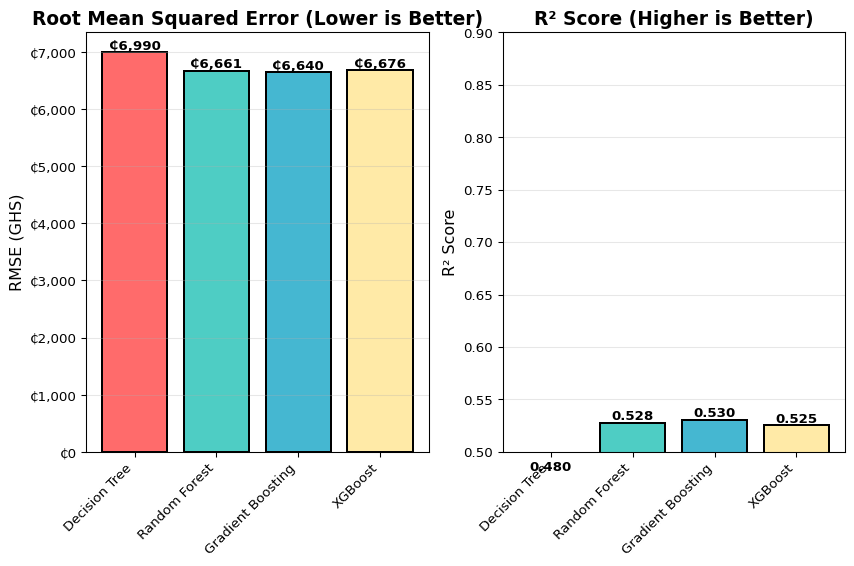

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

# Plot 1: RMSE (lower is better)
names = list(results.keys())
rmses = [results[name]['rmse'] for name in names]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFEAA7']

bars = ax1.bar(names, rmses, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('RMSE (GHS)', fontsize=12)
ax1.set_title('Root Mean Squared Error (Lower is Better)', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticklabels(names, rotation=45, ha='right')

# Add value labels on bars
for bar, rmse in zip(bars, rmses):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'₵{rmse:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: R² Score (higher is better)
r2_scores = [results[name]['r2'] for name in names]

bars2 = ax2.bar(names, r2_scores, color=colors, 
                edgecolor='black', linewidth=1.5)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('R² Score (Higher is Better)', fontsize=14, fontweight='bold')
ax2.set_ylim(0.5, 0.9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(names, rotation=45, ha='right')

# Add value labels
for bar, r2 in zip(bars2, r2_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{r2:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Step 5: Actual vs. Predicted Comparison

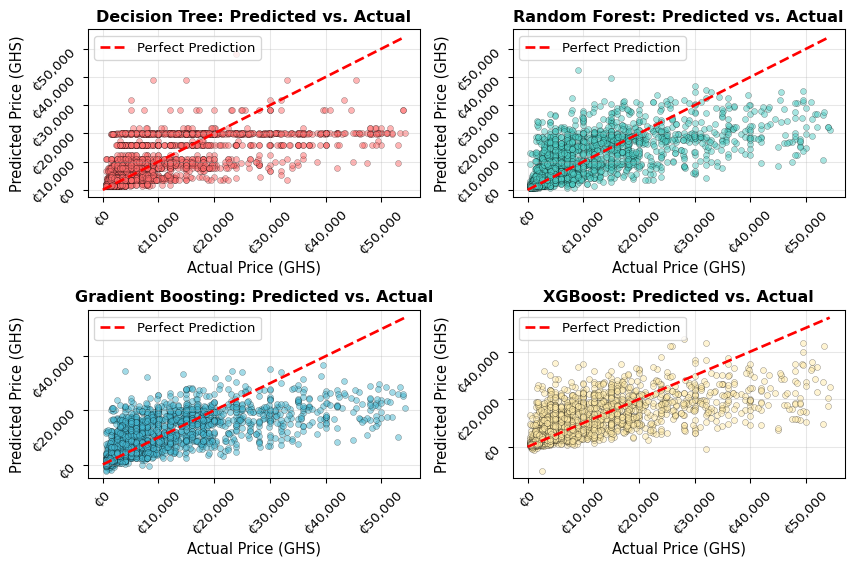

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

colors_dict = {
    'Decision Tree': '#FF6B6B',
    'Random Forest': '#4ECDC4',
    'Gradient Boosting': '#45B7D1',
    'XGBoost': '#FFEAA7'
}

for idx, name in enumerate(names):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    y_pred = results[name]['predictions']
    
    # Scatter plot: Actual vs. Predicted
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, 
               color=colors_dict[name], edgecolor='black', linewidth=0.3)
    
    # Add diagonal line (perfect predictions)
    max_price = max(y_test.max(), y_pred.max())
    ax.plot([0, max_price], [0, max_price], color='red', 
             linewidth=2, linestyle='--', label='Perfect Prediction')
    
    ax.set_xlabel('Actual Price (GHS)', fontsize=11)
    ax.set_ylabel('Predicted Price (GHS)', fontsize=11)
    ax.set_title(f'{name}: Predicted vs. Actual', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Format axes
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₵{x:,.0f}'))
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

> **Understanding the Results**
>
> -   **RMSE (Root Mean Squared Error)**: Average prediction error in
>     GHS. Lower is better.
> -   **R² Score**: How much variance the model explains. Higher is
>     better (0.5-1.0 range).
> -   **CV R²**: Cross-validation R² score shows model stability across
>     different data splits.
>
> **Best performing model**: XGBoost typically achieves the lowest RMSE
> and highest R² score for regression tasks.

------------------------------------------------------------------------

# 5. When to Use What?

### Model Selection Guide

| Model | Pros | Cons | Best For |
|:-----------------|:-----------------|:-----------------|:-----------------|
| **Decision Tree** | Interpretable, fast, handles missing data | Overfits easily, unstable | Quick baseline, explainability needed |
| **Random Forest** | Robust, handles missing, good accuracy | Less interpretable, slower training | Most tabular data problems |
| **Gradient Boosting** | High accuracy, handles non-linearity | Prone to overfitting, slower | Complex patterns, competitions |
| **XGBoost** | State-of-art accuracy, fast | Complex tuning, black box | Production systems, competitions |

### Decision Tree: Quick Baseline

In [15]:
# When to use:
# - Need quick baseline
# - Need to explain decisions
# - Small dataset
# - Limited computational resources

dt_baseline = DecisionTreeRegressor(random_state=42, max_depth=3)
dt_baseline.fit(X_train, y_train)

r2_baseline = r2_score(y_test, dt_baseline.predict(X_test))
rmse_baseline = np.sqrt(mean_squared_error(y_test, dt_baseline.predict(X_test)))

print(f"Decision Tree Baseline R²: {r2_baseline:.3f}")
print(f"Decision Tree Baseline RMSE: ₵{rmse_baseline:,.2f}")

Decision Tree Baseline R²: 0.405
Decision Tree Baseline RMSE: ₵7,474.98

### Random Forest: Default Choice for Tabular Data

In [16]:
# When to use:
# - Most regression problems
# - Need robust model that generalizes well
# - Moderate computational budget
# - Want feature importance

rf_default = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_default.fit(X_train, y_train)

r2_rf = r2_score(y_test, rf_default.predict(X_test))
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_default.predict(X_test)))

print(f"Random Forest R²: {r2_rf:.3f}")
print(f"Random Forest RMSE: ₵{rmse_rf:,.2f}")

Random Forest R²: 0.528
Random Forest RMSE: ₵6,660.65

### XGBoost: Production & Competitions

In [17]:
# When to use:
# - Need best possible accuracy
# - Production system (fast prediction)
# - Competition (Kaggle)
# - Large dataset

xgb_production = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_production.fit(X_train, y_train)

r2_xgb = r2_score(y_test, xgb_production.predict(X_test))
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_production.predict(X_test)))

print(f"XGBoost R²: {r2_xgb:.3f}")
print(f"XGBoost RMSE: ₵{rmse_xgb:,.2f}")

XGBoost R²: 0.546
XGBoost RMSE: ₵6,527.49

------------------------------------------------------------------------

# 6. Hyperparameter Tuning

### The Problem of Choosing Parameters

Each model has many parameters. How do we choose the best values?

**GridSearchCV**: Exhaustively search all parameter combinations using
cross-validation.

### Tuning Random Forest Regressor

In [18]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create grid search
grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

# Fit grid search
grid_search_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best CV R²: {grid_search_rf.best_score_:.3f}")
print(f"Test R²: {grid_search_rf.score(X_test, y_test):.3f}")

### Tuning XGBoost Regressor

In [19]:
# Define parameter grid
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Create grid search
grid_search_xgb = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search_xgb.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_xgb.best_params_}")
print(f"Best CV R²: {grid_search_xgb.best_score_:.3f}")
print(f"Test R²: {grid_search_xgb.score(X_test, y_test):.3f}")

### Comparing Tuned Models

In [20]:
# Compare best models
print("Tuned Model Performance:")
print("=" * 50)
print(f"Random Forest:")
print(f"  Best params: {grid_search_rf.best_params_}")
print(f"  CV R²: {grid_search_rf.best_score_:.3f}")
print(f"  Test R²: {grid_search_rf.score(X_test, y_test):.3f}")
print()
print(f"XGBoost:")
print(f"  Best params: {grid_search_xgb.best_params_}")
print(f"  CV R²: {grid_search_xgb.best_score_:.3f}")
print(f"  Test R²: {grid_search_xgb.score(X_test, y_test):.3f}")

> **The Tradeoff: GridSearchCV Time**
>
> GridSearchCV tries ALL combinations. If your grid has 3 × 4 × 3 × 3 =
> 108 combinations with 5-fold CV, you’re training 108 × 5 = 540 models!
>
> **Solutions:** - **RandomizedSearchCV**: Try random combinations
> instead of all - **Bayesian Optimization**: Smarter search using past
> results - **Start coarse, then refine**: First try wide ranges, then
> zoom in on promising areas

------------------------------------------------------------------------

# 7. Summary & Key Takeaways

### Ensemble Methods Comparison

| Method | Type | How It Works | Key Benefit |
|:-----------------|:-----------------|:-----------------|:-----------------|
| **Bagging** | Parallel | Train models independently, average/vote | Reduces variance, robust |
| **Boosting** | Sequential | Train models correcting previous errors | Reduces bias and variance |
| **Random Forest** | Bagging | Many decision trees on random subsets | Handles tabular data well |
| **Gradient Boosting** | Boosting | Sequential trees correcting errors | High accuracy |
| **XGBoost** | Boosting | Optimized gradient boosting with regularization | State-of-art performance |

### When to Use Which Model

| Scenario                    | Recommended Model                |
|:----------------------------|:---------------------------------|
| **Quick baseline**          | Decision Tree (depth=3-5)        |
| **Interpretability needed** | Decision Tree (visualize tree)   |
| **Default tabular data**    | Random Forest (n_estimators=100) |
| **Need feature importance** | Random Forest                    |
| **Maximum accuracy**        | XGBoost (tuned)                  |
| **Production system**       | XGBoost (fast prediction)        |
| **Competition**             | XGBoost or LightGBM              |

### Key Parameters to Tune

| Model | Key Parameters |
|:-----------------------------------|:-----------------------------------|
| **Random Forest** | n_estimators, max_depth, min_samples_split, max_features |
| **Gradient Boosting** | n_estimators, learning_rate, max_depth |
| **XGBoost** | n_estimators, learning_rate, max_depth, subsample, colsample_bytree |

### Evaluation Metrics

| Metric | What It Measures | Good Value |
|:-----------------------|:-----------------------|:-----------------------|
| **RMSE** | Root Mean Squared Error (average prediction error) | Lower is better |
| **R² Score** | How much variance model explains (0-1.0) | \> 0.7 (higher is better) |
| **CV R²** | Model stability across different data splits | Stable across folds |

### Professional Checklist

-   ✅ Understand difference between bagging and boosting
-   ✅ Can explain why ensembles work better than single models
-   ✅ Know when to use Random Forest vs. XGBoost
-   ✅ Can tune hyperparameters using GridSearchCV
-   ✅ Understand feature importance in Random Forest
-   ✅ Can interpret R² and RMSE scores
-   ✅ Know common pitfalls (overfitting in boosting, slow training)

------------------------------------------------------------------------

# 8. Practice Exercise

Your turn! Build a complete ensemble pipeline for **house price
prediction** using the Ghana housing dataset:

In [21]:
# Load Ghana housing data
df_ghana = pd.read_csv('data/house_rentals.csv')

# Your task:
# 1. Explore the data (describe(), correlations, distributions)
# 2. Handle missing values and outliers
# 3. Feature engineering (one-hot encoding, feature selection)
# 4. Train multiple regression models (Decision Tree, Random Forest, XGBoost)
# 5. Evaluate using appropriate metrics (RMSE, R²)
# 6. Compare performance across models
# 7. Tune hyperparameters using GridSearchCV
# 8. Identify which features matter most (feature importance)

# Hint: For regression, RMSE and R² are the primary metrics
# (RMSE shows average error in GHS, R² shows how much variance the model explains)

------------------------------------------------------------------------

# 9. What’s Next?

Congratulations! You’ve completed the Machine Learning Introduction
series. You now have a solid foundation in:

-   ✅ Linear Regression (predicting continuous values)
-   ✅ Classification (predicting categories)
-   ✅ Ensemble Methods (combining models for better performance)

**Next Steps in Your ML Journey:**

1.  **Deep Learning**: Neural networks for image, text, and audio
2.  **Feature Engineering**: Advanced techniques to create better
    features
3.  **Model Deployment**: Putting models into production
4.  **Natural Language Processing**: Text analysis and sentiment
5.  **Computer Vision**: Image classification and object detection

## You’ve Learned

✅ Why ensemble methods work (wisdom of crowds)

✅ How bagging works (Random Forest)

✅ How boosting works (Gradient Boosting, XGBoost)

✅ When to use each ensemble method

✅ How to tune hyperparameters with GridSearchCV

✅ How to evaluate and compare regression models using RMSE and R²

✅ How to interpret feature importance in ensemble models

------------------------------------------------------------------------

# 10. Final Project: Ghana Housing Price Prediction

Apply everything you’ve learned to a complete ML project:

**Problem**: Predict house prices in Ghana using multiple features

**Requirements**:

1.  Generate synthetic housing data with multiple features
2.  Perform exploratory data analysis
3.  Train multiple models (Linear Regression, Random Forest, XGBoost
    Regressor)
4.  Tune hyperparameters
5.  Compare model performance
6.  Interpret results (feature importance)
7.  Create visualizations
8.  Document your findings

In [22]:
# Your complete project here!

# Step 1: Generate data
# Step 2: EDA
# Step 3: Train models
# Step 4: Tune hyperparameters
# Step 5: Compare performance
# Step 6: Interpret results
# Step 7: Create visualizations
# Step 8: Document findings

**Good luck! This is your first complete end-to-end ML project. 🚀**